# 03 · DRAG: taming leakage and phase errors of short pulses

A short Gaussian pulse on the 0–1 transition also drives the 1–2 transition (their frequencies differ only by the
anharmonicity, −0.31 GHz); a pulse on 1–2 leaks into 0–1 and 2–3 and, worse, shifts the phase of the level it is not
supposed to touch. *Derivative Removal by Adiabatic Gate* (DRAG) adds a quadrature component $\beta\,\dot\Omega/\alpha$ to the pulse;
the whole game is finding $\beta$ (and sometimes a detuning) for *our* 1–2 pulses, where the two neighbouring transitions pull in
opposite directions.

The shop tried four ways to measure $\beta$, in this order:

1. **Pseudo-identity pairs (2022, Oslo/Manila; 2023, Brisbane "DRAG v1")** — $(X_\pi X_{-\pi})^n$ at the DRAG parameter swept; the
   return population oscillates in $\beta$ with a period that shrinks with $n$, the optimum is the common maximum.
2. **2-D maps of $\beta$ × detuning (Dec 2023, "DRAG v3 / YZ")** — the Y and Z corrections of Lucero 2010 together.
3. **Amplified phase error, APE (Lucero 2010), adapted to 1–2 (2024)** — SX12, $n$ pseudo-identities, a final SX12 at the phase
   where the fringe is steepest; the leakage-induced phase error grows linearly with $n$ and vanishes at the right $\beta$.
4. **DRAPE (2025, the paper)** — APE with a $\beta$ sweep: $P_2$ versus $\beta$ is a straight line whose slope grows with $n$,
   and all lines cross at the correct $\beta$ (≈ −0.41 for the 20 ns pulse).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, glob, os, json
import matplotlib.pyplot as plt
from pulseshop import readout, io, fitting, qutrit, constants as C
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. 2022 — $(X_\pi X_{-\pi})^n$ sweeps on `ibm_oslo`

The circuit factory of `Pulses/Full Calibration/DRAG_calibration_01.ipynb` is `pulseshop.schedules.drag_sweep_circuits`;
the results of Nov 2022 (OSLO-B pulses, 320 dt) are kept as figures:

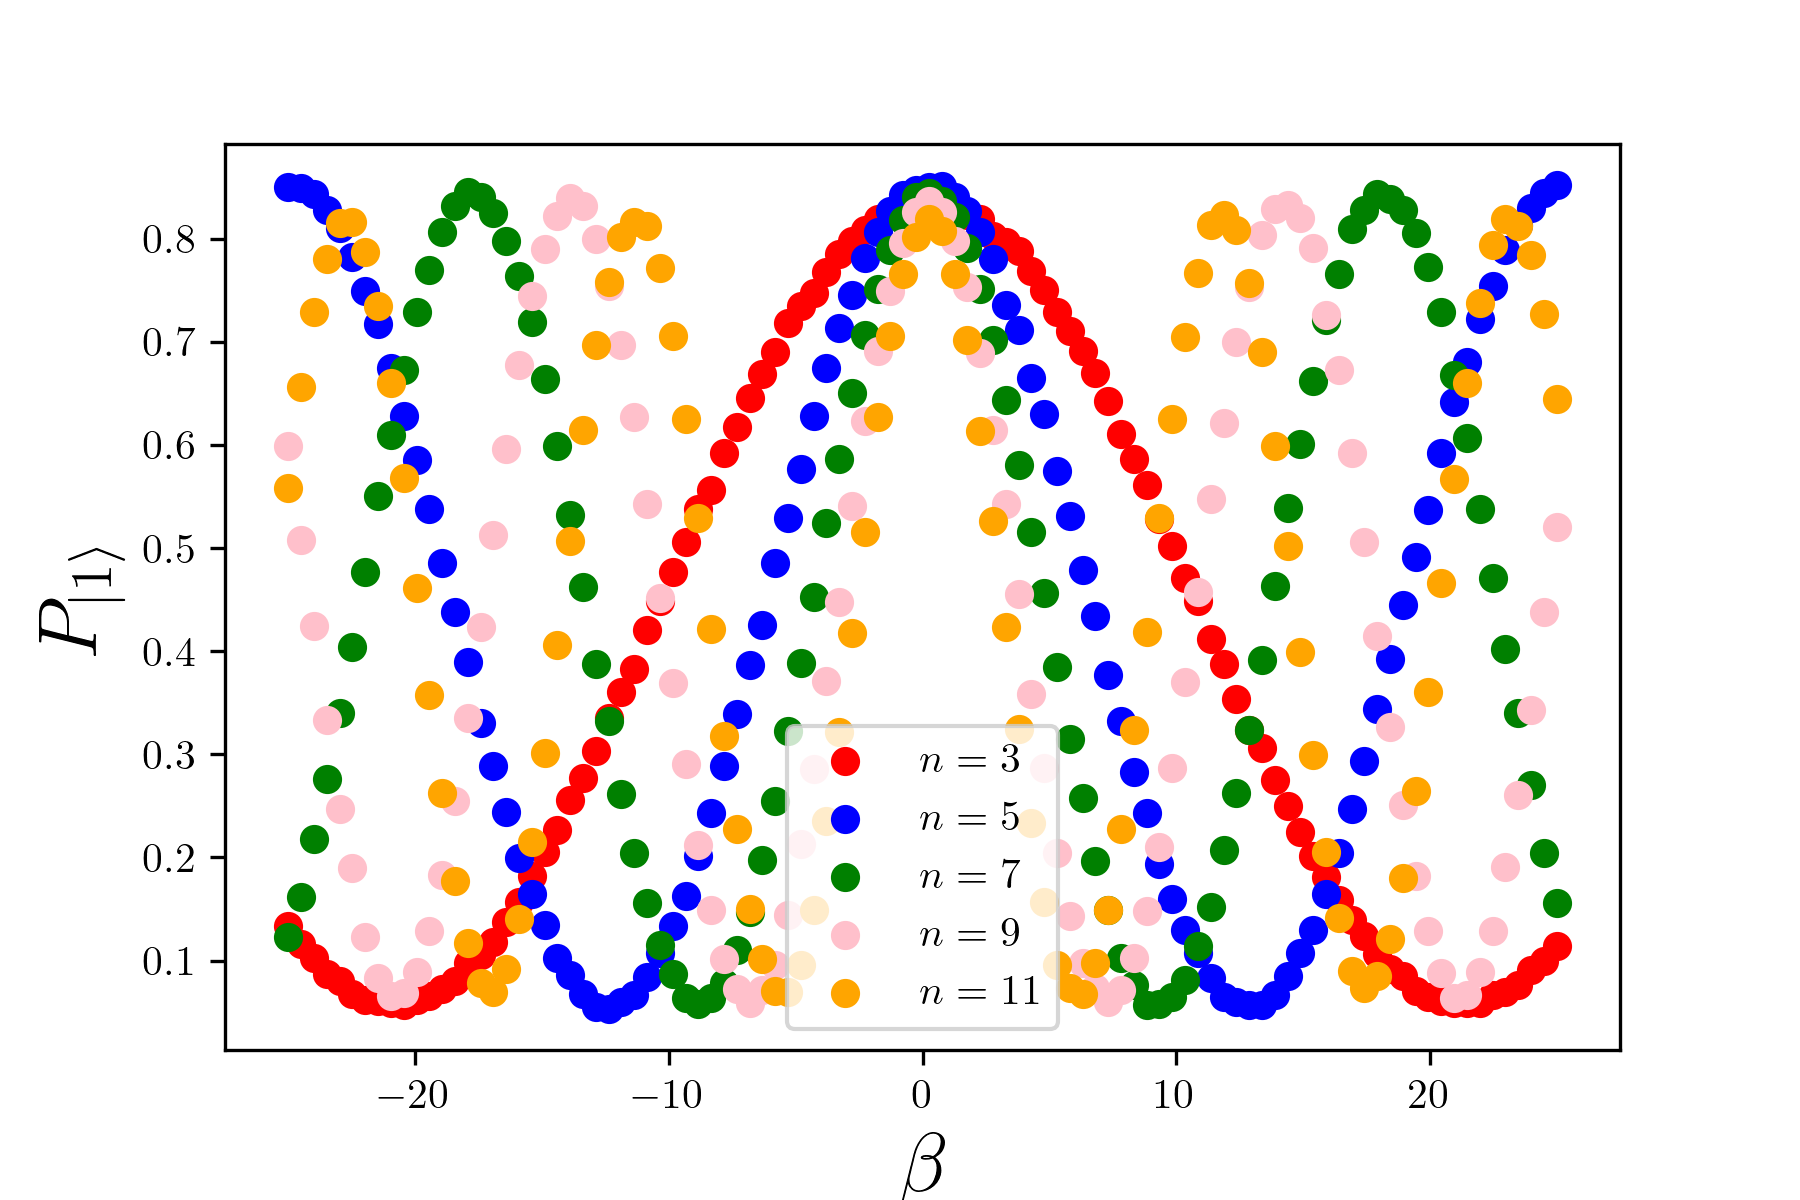

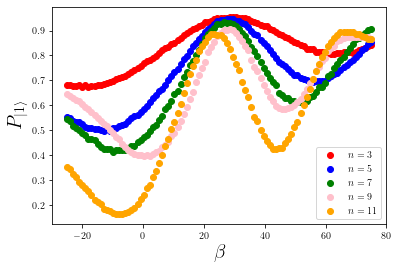

In [2]:
from IPython.display import Image, display
display(Image(filename=str(io.FIG_DIR / "lab_2022/oslo_q0_2022-10_drag01_beta_sweep.png"), width=420))
display(Image(filename=str(io.FIG_DIR / "lab_2022/oslo_q0_2022-10_drag12_beta_sweep.png"), width=420))

For 0–1 (first figure) the return probability $P_1$ oscillates in $\beta$ and the curves of $n = 3 … 11$ share a maximum at $\beta_{01} \approx -0.17$
(the Nov 2022 value; −0.056 to +0.14 in other runs — the 320 dt pulse hardly needs DRAG). For 1–2 (second figure) the signal is a slow
hump around $\beta_{12} \approx 25$–$50$ in these units and the over-rotation of the X12 pulse dominates; this method was abandoned for 1–2.

## 2. Dec 2023 — DRAG v1 on `ibm_brisbane` qubit 109 (96 dt pulse)

Same pseudo-identity idea, shorter pulse, single-shot readout with `DataAnalysis`. The saved populations are the mitigated
$P_0, P_1, P_2$ for each repetition count.

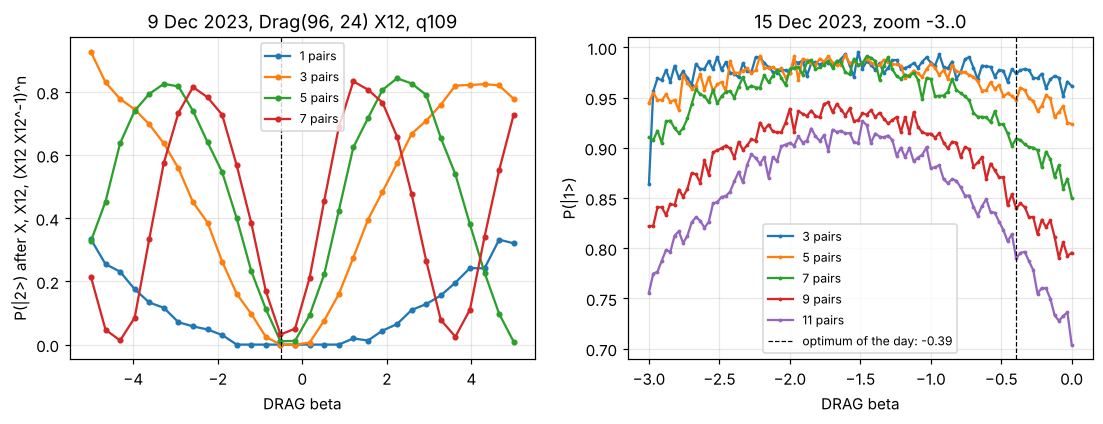

In [3]:
def load_dragv1(day, prefix, reps, n):
    out = {}
    for r in reps:
        try:
            out[r] = np.array([io.load_npy(f"shop_2023_legacy/calibrator/dragv1/data/{day}", f"{prefix}{k}_{r}rep.npy" if prefix == "state" else f"{prefix}{k}_rep{r}.npy") for k in range(3)])
        except FileNotFoundError:
            pass
    return out

d9 = load_dragv1("9dec", "state", [1, 3, 5, 7], 30)
d15 = load_dragv1("15dec", "state", [3, 5, 7, 9, 11], 100)
betas9 = np.linspace(-5, 5, 30)
betas15 = np.linspace(-3, 0, 100)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for r, pops in d9.items():
    axes[0].plot(betas9, pops[2], ".-", label=f"{r} pairs")
axes[0].set(xlabel="DRAG beta", ylabel="P(|2>) after X, X12, (X12 X12^-1)^n", title="9 Dec 2023, Drag(96, 24) X12, q109")
axes[0].axvline(-0.5, color="k", ls="--", lw=0.8); axes[0].legend(fontsize=8)
for r, pops in d15.items():
    axes[1].plot(betas15, pops[1], ".-", ms=3, label=f"{r} pairs")
axes[1].set(xlabel="DRAG beta", ylabel="P(|1>)", title="15 Dec 2023, zoom -3..0")
axes[1].axvline(betas15[86], color="k", ls="--", lw=0.8, label=f"optimum of the day: {betas15[86]:.2f}"); axes[1].legend(fontsize=8)
io.save_fig(fig, "03_dragv1_q109_dec2023")

The maximum of $P_2$ (minimum of $P_1$) sits at $\beta \approx -0.4$ to $-0.5$ for the 96 dt pulse — the number used until the pulse was shortened again.

A detuning sweep (11 Dec) with DRAG applied shows the Z-correction side: the pseudo-identity is only an identity at the right drive frequency.

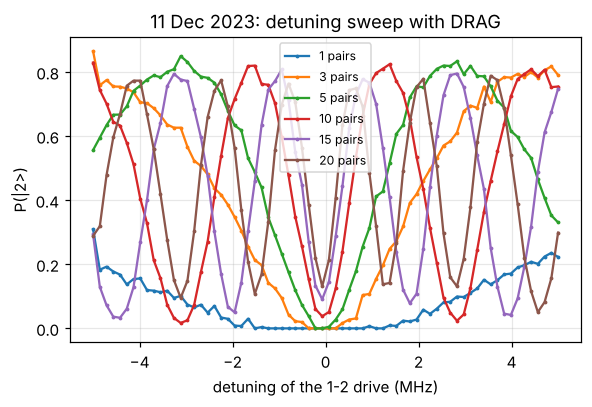

In [4]:
d11 = load_dragv1("11dec", "st", [1, 3, 5, 10, 15, 20], 70)
det = np.linspace(-5, 5, 70)
fig, ax = plt.subplots(figsize=(6, 3.6))
for r, pops in d11.items():
    ax.plot(det, pops[2], ".-", ms=3, label=f"{r} pairs")
ax.set(xlabel="detuning of the 1-2 drive (MHz)", ylabel="P(|2>)", title="11 Dec 2023: detuning sweep with DRAG")
ax.legend(fontsize=8)
io.save_fig(fig, "03_dragv1_detuning_q109_dec2023")

## 3. Dec 2023 — the $\beta$ × detuning maps (DRAG v3)

`calibrator/dragv3/YZ.ipynb` swept both at once with the APE sequence on the 1–2 half-$\pi$ pulse (3 pseudo-identities).
The 22 Dec map is 15 detunings (−4.5 … 1.9 MHz) × 30 betas (−5 … 3). (The 15–19 Dec maps are 25 × 20 grids; the surviving notebook does
not define their axes, but the saved figures show them — e.g. 17 Dec: detuning −0.5 … 0.25 MHz × β −0.8 … 0 — see
`figures/shop_2023_legacy/*dragv3*` and `data/shop_2023_legacy/calibrator/dragv3/`.)

best detuning row: -4.5 MHz


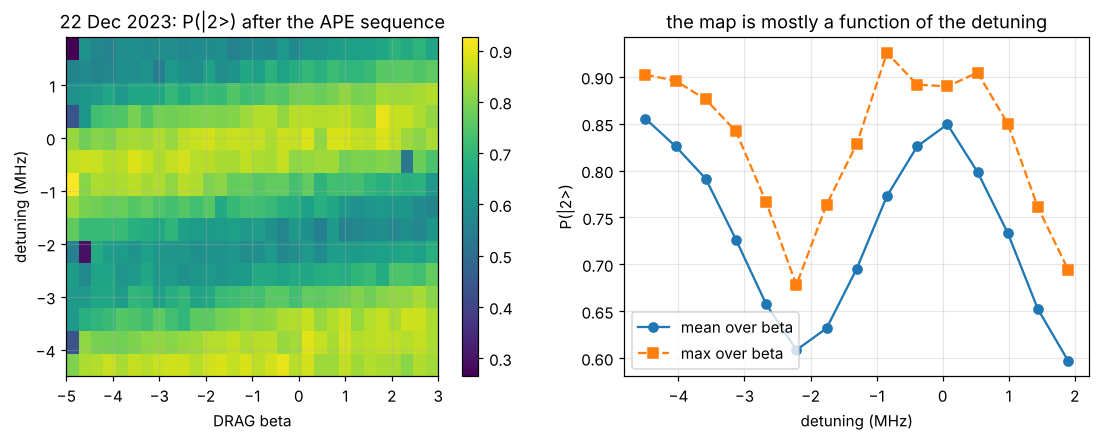

In [5]:
yz22 = io.load_npy("shop_2023_legacy/calibrator/dragv3/data/22dec", "YZ_data_2D.npy")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(yz22, origin="lower", aspect="auto", extent=[-5, 3, -4.5, 1.9], cmap="viridis")
axes[0].set(xlabel="DRAG beta", ylabel="detuning (MHz)", title="22 Dec 2023: P(|2>) after the APE sequence")
plt.colorbar(im, ax=axes[0])
dets = np.linspace(-4.5, 1.9, 15)
axes[1].plot(dets, yz22.mean(axis=1), "o-", label="mean over beta")
axes[1].plot(dets, yz22.max(axis=1), "s--", label="max over beta")
axes[1].set(xlabel="detuning (MHz)", ylabel="P(|2>)", title="the map is mostly a function of the detuning")
axes[1].legend()
print("best detuning row:", round(dets[np.argmax(yz22.mean(axis=1))], 2), "MHz")
io.save_fig(fig, "03_dragv3_beta_detuning_maps")

At this pulse length (96 dt) the APE response is dominated by the detuning: the bright rows are the drive frequencies at which the
pseudo-identities really are identities, and the $\beta$ dependence within a row is weak. The Y and Z corrections of Lucero 2010
are entangled in such a map (a wrong $\beta$ can be partly compensated by a detuning), so keeping the drive on resonance and tuning only $\beta$ is the cleaner choice,
and that is what the 2024–25 work did (notebook 01 showed the Ramsey measurements that pin the 1–2 frequency).

The one-dimensional cuts of 19 Dec (`onlyY`, `onlyZ`) make the same point: APE with only the Y correction or only the detuning.

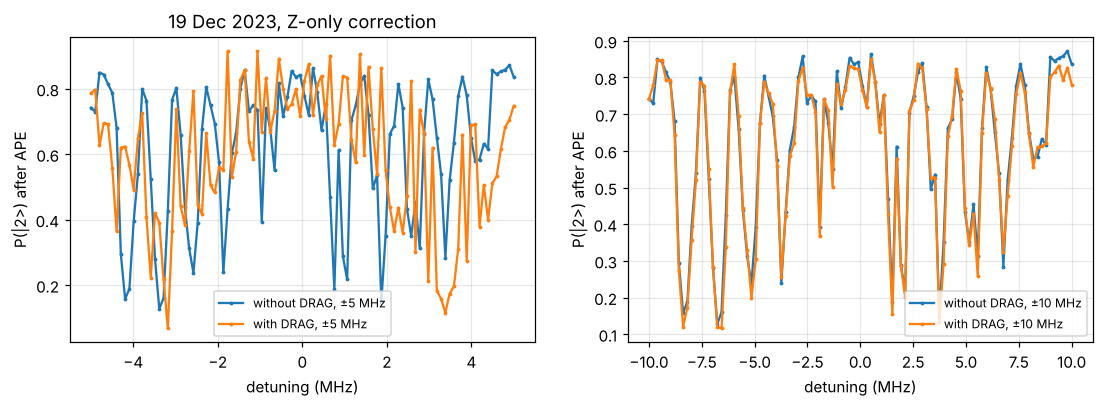

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for name, lab in [("Z_data_1D_woD_m5_5MHz", "without DRAG, ±5 MHz"), ("Z_data_1D_wD_m5_5MHz", "with DRAG, ±5 MHz")]:
    y = io.load_npy("shop_2023_legacy/calibrator/onlyZ/data/19dec", name + ".npy")
    axes[0].plot(np.linspace(-5, 5, len(y)), y, ".-", ms=3, label=lab)
for name, lab in [("Z_data_1D_woD_m10_10MHz", "without DRAG, ±10 MHz"), ("Z_data_1D_wD_m10_10MHz", "with DRAG, ±10 MHz")]:
    y = io.load_npy("shop_2023_legacy/calibrator/onlyZ/data/19dec", name + ".npy")
    axes[1].plot(np.linspace(-10, 10, len(y)), y, ".-", ms=3, label=lab)
for ax in axes:
    ax.set(xlabel="detuning (MHz)", ylabel="P(|2>) after APE"); ax.legend(fontsize=8)
axes[0].set_title("19 Dec 2023, Z-only correction")
io.save_fig(fig, "03_onlyZ_q109_dec2023")

## 4. May 2024 — APE + DRAG sweeps on the 64 dt pulse

`calibrator/ape_drag/ape_drag.ipynb` ran the APE sequence (SX12, $n$ pseudo-identities, final −SX12 at phase 0) for
$n = 3, 5, 7, 9$ while sweeping $\beta$ from −2 to 1 (150 points) and recorded the mitigated $P_2$ — the leakage left behind.
Its minimum is the $\beta$ that cancels the phase error; the fits of the day gave −0.44 (X12) and −0.49 … −0.54 (SX12).

parabola minima inside -1.3..0.3: [-0.486 -0.544 -0.494 -0.535 -0.394 -0.435 -0.476 -0.49  -0.58  -0.54
 -0.601 -0.593 -0.422 -0.515 -0.484 -0.472 -0.52  -0.509 -0.518 -0.537
 -1.052] -> mean -0.533


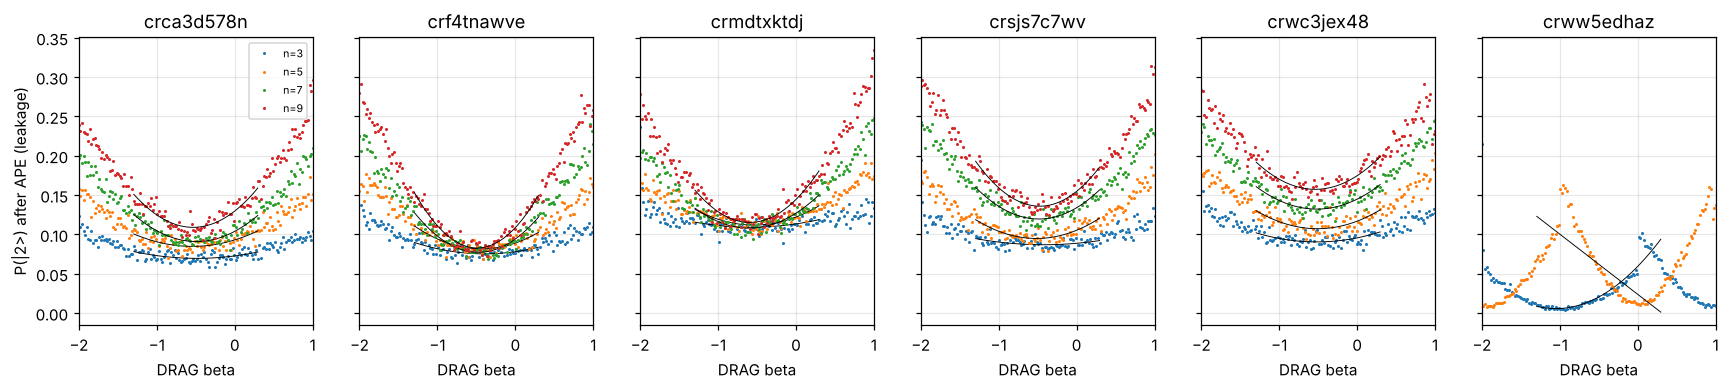

In [7]:
betas = np.linspace(-2, 1, 150)
runs = sorted(glob.glob(str(io.data_path("shop_2023_legacy/calibrator/ape_drag/data/ape_drag/pop2_sx12_*_-2_to_1_3577.npy"))))
fig, axes = plt.subplots(1, len(runs), figsize=(3.2 * len(runs), 3.4), sharey=True)
minima = []
for ax, f in zip(np.atleast_1d(axes), runs):
    arr = np.load(f); nrep = arr.size // 150
    p2 = arr.reshape(nrep, 150)
    for k, n in enumerate([3, 5, 7, 9][-nrep:]):   # the file-name suffix lists the repetitions; one run kept only the last two
        ax.plot(betas, p2[k], ".", ms=2, label=f"n={n}")
        w = (betas > -1.3) & (betas < 0.3)
        try:
            pars, yfit, _ = fitting.fit_function(betas[w], p2[k][w], fitting.parabola, [0.1, -0.5, p2[k][w].min()])
            ax.plot(betas[w], yfit, "k-", lw=0.6)
            if -1.3 < pars[1] < 0.3 and pars[0] > 0:
                minima.append(pars[1])
        except RuntimeError:
            pass
    ax.set(xlabel="DRAG beta", title=os.path.basename(f).split("_")[2][:10], xlim=(-2, 1))
np.atleast_1d(axes)[0].set_ylabel("P(|2>) after APE (leakage)"); np.atleast_1d(axes)[0].legend(fontsize=7)
io.save_fig(fig, "03_ape_drag_beta_sweeps_may2024")
print("parabola minima inside -1.3..0.3:", np.round(minima, 3), "-> mean", round(float(np.mean(minima)), 3))

The parabola minima scatter around −0.53 ± 0.05, consistent with the −0.49 … −0.54 recorded in May 2024. The minimum is shallow,
which is why the next two campaigns moved the final pulse to the *sensitive phase* of the fringe, where the response is linear in $\beta$.

## 5. Jul 2024 — the 120 dt SX12 pulse (`calibrator/phase_error/qubit109`)

Before the final shortening the same APE+DRAG sweep was done on a 120 dt SX12 with $n = 7, 9, 11, 13, 15$ pseudo-identities,
$\beta$ from −1 to 0 (100 points, the range used in the fit cell of the notebook), the final pulse at the $\pi$ point where the response
is parabolic. The raw IQ shots are in `48dt/round8_ad_7_9_11_13_15_pi` (the first three circuits are the calibration circuits):

LDA score 0.842 confusion diag [0.822 0.87  0.86 ]
parabola minima: [-0.49  -0.458 -0.463 -0.441 -0.45 ] -> mean beta = -0.46 (notebook: -0.4601)


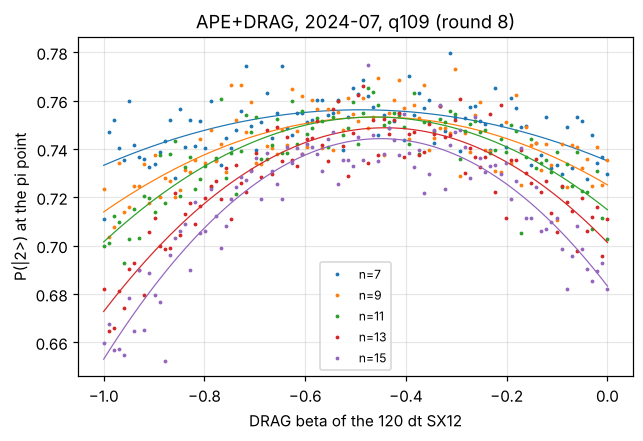

In [8]:
iq = io.load_npy("shop_2024/calibrator/phase_error/qubit109/data/48dt", "round8_ad_7_9_11_13_15_pi.npy")
da = readout.DataAnalysis(iq); pops = da.run()
print("LDA score", round(da.score_012, 3), "confusion diag", np.round(np.diag(da.confusion_mat), 3))
betas = np.linspace(-1.0, 0.0, 100)
p2 = da.raw_counted[3:, 2].reshape(5, 100)      # the notebook fitted the raw (unmitigated) P2
fig, ax = plt.subplots(figsize=(6.5, 4))
x0s = []
for k, n in enumerate([7, 9, 11, 13, 15]):
    ax.plot(betas, p2[k], ".", ms=3, color=f"C{k}", label=f"n={n}")
    pars, yfit, _ = fitting.fit_function(betas, p2[k], fitting.parabola, [-1, -0.5, p2[k].max()])
    ax.plot(betas, yfit, "-", color=f"C{k}", lw=0.8)
    x0s.append(pars[1])
ax.set(xlabel="DRAG beta of the 120 dt SX12", ylabel="P(|2>) at the pi point", title="APE+DRAG, 2024-07, q109 (round 8)")
ax.legend(fontsize=8)
io.save_fig(fig, "03_ape_drag_120dt_jul2024")
print("parabola minima:", np.round(x0s, 3), "-> mean beta =", round(np.mean(x0s), 3), "(notebook: -0.4601)")

## 6. Jan 2025 — DRAPE on the 20 ns pulse (the paper's Fig. 2 inset / `drape.png`)

`calibrator/drape/drape_script.ipynb`: X, SX12($\beta$), $n$ × (SX12, −SX12), an X12 – delay – −X12 echo, −SX12 at phase $\pi/2$, X, measure,
with the radius discriminator of notebook 02. Near the optimum $P_2(\beta)$ is linear and the lines for different $n$ cross
where the phase error is zero.

cybdjk2cw2k0008kfs10 lines cross at beta = [-0.418 -0.418 -0.418] | mean -0.418
cyf2m287v8tg008hdsx0 lines cross at beta = [-0.421 -0.413 -0.405] | mean -0.413


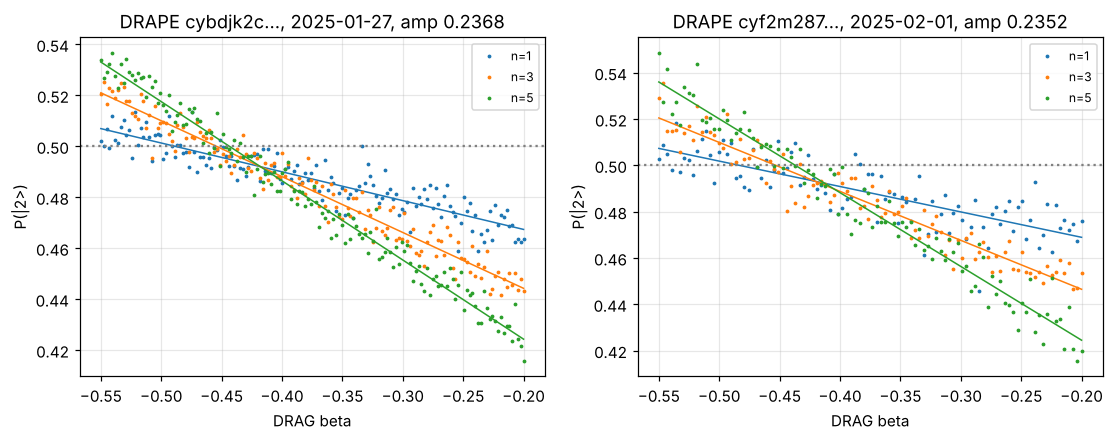

In [9]:
rd = io.load_json("pending_2025", "rabi_discrim.json")
radius = readout.RadiusDiscriminator(complex(rd["cluster_0_mean"]["re"], rd["cluster_0_mean"]["im"]), complex(rd["cluster_2_mean"]["re"], rd["cluster_2_mean"]["im"]), rd["radius_fit"])

def drape(job):
    iq, prm = io.load_job(f"pending_2025/calibrator/drape/data/{job}")
    pops = readout.count(iq, radius)
    nb = prm["num_betas"]; reps = prm["rep_range"]
    betas = np.linspace(prm["beta_min"], prm["beta_max"], nb)
    return betas, reps, pops[:, 2].reshape(len(reps), nb), prm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, job in zip(axes, ["cybdjk2cw2k0008kfs10", "cyf2m287v8tg008hdsx0"]):
    betas, reps, p2, prm = drape(job)
    lines = []
    for k, n in enumerate(reps):
        ax.plot(betas, p2[k], ".", ms=3, color=f"C{k}", label=f"n={n}")
        m, c = np.polyfit(betas, p2[k], 1); lines.append((m, c))
        ax.plot(betas, m * betas + c, "-", color=f"C{k}", lw=1)
    ax.axhline(0.5, color="grey", ls=":")
    ax.set(xlabel="DRAG beta", ylabel="P(|2>)", title=f"DRAPE {job[:8]}…, {prm['datetime'][:10]}, amp {prm['amp_sx12']:.4f}")
    ax.legend(fontsize=8)
    # pairwise crossings of the lines
    xs = [(lines[j][1] - lines[i][1]) / (lines[i][0] - lines[j][0]) for i in range(len(lines)) for j in range(i + 1, len(lines))]
    print(job, "lines cross at beta =", np.round(xs, 3), "| mean", round(float(np.mean(xs)), 3))
io.save_fig(fig, "03_drape_q109_jan2025")

Both January runs put the crossing at $\beta \approx -0.41$, the value the paper's scripts use for every rotation-error, APE and
phase-advance run (β = −0.414; `sx12_params.json` itself stores β = 0 and the scripts override it). The
second run (1 Feb, amplitude 0.23525) was an attempt to re-focus the fringe against dephasing; it is noisier but gives the same number.

## 7. Where the numbers ended up

| pulse | duration | $\beta$ | method | year |
|---|---|---|---|---|
| X01, ibm_oslo q0 | 320 dt | −0.17 | pseudo-identity pairs | 2022 |
| X12, ibm_brisbane q109 | 96 dt | −0.4 … −0.5 | pseudo-identity pairs (v1), YZ maps (v3) | Dec 2023 |
| X12 / SX12, q109 | 64 dt | −0.445 / −0.49 | APE + DRAG | May 2024 |
| SX12, q109 | 120 dt | −0.46 | APE + DRAG, parabola | Jul 2024 |
| SX12, q109 | 40 dt | −0.414 | DRAPE | Jan 2025 |

$\beta$ barely depends on the pulse length once expressed in Qiskit's units — it is a property of the qubit's anharmonicity more than of the pulse.
Notebook 04 shows what the correction does to the error budget.